<a href="https://colab.research.google.com/github/Luuuuuig/Bachelor-End-Project/blob/main/Arno_Analysis_2026_10_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arno: first analysis after the supervisor meeting
**2 October 2026 · Review draft · Five sessions, 31 August to 23 September**

This starts the analysis requested in the 1 October meeting. Inputs are the five original daily CSVs, their observation notes, the protocol and the time register. Existing files in `analysis/` were not used. Nothing has been committed or pushed.

## tl;dr

- **Investigate Ordering first:** 341 of 743 recorded activity minutes (45.9%); it is the largest recorded stage on each day. A stage is a focus area, not yet a selected AI task.
- **Retain aftercare:** OTHER totals 259 minutes (34.9%), comprising 182 originally EXC and 77 originally OTHER. Original OTHER also contains ordinary purchasing work.
- **Explore CHECK with care:** the usable comparison is 62 minutes / 71 lines = 0.87 minutes per line. Daily ratios still vary, check types differ, and most denominators are proxies. This is not a validated fixed time per line.
- **Next substantive work:** inspect information/document completeness within Ordering and compare it with a clearly defined CHECK task. Establish buyer acceptance and feasible data access before choosing functionality.

The instruction to begin analysis is clear. A further broad sufficiency exercise is not a prerequisite for these descriptive findings.

## Context & Methods

**Question:** where does Arno's observed purchasing work concentrate, and which specific tasks deserve closer investigation under the supervisor's clarified scope?

The [1 October minutes](../docs/meetings/Academic_Supervisor_Meeting_Notes_2026-10-01.md) establish four working decisions: start with Arno, retain aftercare under OTHER but outside improvement scope, retain work outside the purchasing framework, and compare CHECK with order-line volume before reconsidering stability. Dennis can be revisited later.

The methods follow a descriptive EDA workflow: load and inspect records, group and sum, compare distributions, inspect cases, plot relationships and calculate pooled ratios. No hypothesis test, regression, new pass/fail rule or saturation claim is needed for these questions.

### Key Assumptions

| Choice | Treatment |
|---|---|
| Unit of analysis | A recorded activity segment or tally; a row is not necessarily a complete task or order. |
| Duration | End minus start when both are recorded; otherwise missing, never imputed as zero or one minute. |
| Lost focus | Preserve the two 8 September OBS-16 rows, but exclude their nine minutes and rows from descriptive comparisons. |
| EXC | Report under OTHER; preserve original code and outside-scope flag. |
| Stage | Use the stage written in the CSV; keep blanks as Unassigned. |
| Percentage denominator | Sum of retained recorded activity durations, including EXC and work outside the framework. |
| CHECK line volume | Use explicit checked-line counts where given; otherwise an order-size proxy. Correct split segments and exclude documented incomplete checks from ratios only. |
| Generalisation | These are five sessions for one buyer; dates, case labels and repeated segments are not independent random samples of all purchasing work. |

Source snapshot: [`2a8fa34f0d8b8fc0f4f5928b25acbda58c52f57d`](https://github.com/Luuuuuig/Bachelor-End-Project/commit/2a8fa34f0d8b8fc0f4f5928b25acbda58c52f57d). Exact input paths and hashes are in [source_manifest.json](output/source_manifest.json). Code is in [analyze_arno.py](analyze_arno.py).

In [2]:
import pandas as pd

# GitHub version containing your REQ correction
commit = "0510b1cb1edc6d5cc6af40c18c903d1052eab7fe"
base_url = (
    "https://raw.githubusercontent.com/"
    f"Luuuuuig/Bachelor-End-Project/{commit}/docs/measurement/"
)

dates = [
    "2026-08-31",
    "2026-09-01",
    "2026-09-08",
    "2026-09-18",
    "2026-09-23"
]

# Read each day and make the column names consistent
frames = []

for date in dates:
    df = pd.read_csv(
        base_url + f"Arno_Measurement_{date}.csv",
        encoding="utf-8-sig",
        na_values=["—"]
    )

    df = df.rename(columns={
        "Activity as written": "Activity",
        "Result / short note": "Note"
    })

    df["date"] = pd.to_datetime(date)
    df["source_row"] = df.index + 1
    frames.append(df)

# Combine the five days
observations = pd.concat(frames, ignore_index=True)
observations["weekday"] = observations["date"].dt.day_name()

# Calculate durations. Untimed tallies remain missing, not zero.
start = pd.to_datetime(
    observations["Start"], format="%H:%M", errors="coerce"
)
end = pd.to_datetime(
    observations["End"], format="%H:%M", errors="coerce"
)

observations["minutes"] = (end - start).dt.total_seconds() / 60

# Exclude the documented lost-focus episode from analysis
lost_focus = (
    observations["date"].eq(pd.Timestamp("2026-09-08"))
    & observations["Case"].eq("OBS-16")
)

included = observations.loc[~lost_focus].copy()

print("Original records:", len(observations))
print("Records included:", len(included))
print("Recorded minutes:", included["minutes"].sum())

included.head()

Original records: 287
Records included: 285
Recorded minutes: 742.0


,Case,Activity,Start,End,Volume,INT,DEC?,Note,Van Weele stage,date,source_row,weekday,minutes
0,OBS-01,REQ,NaN,NaN,NaN,0,NaN,Item: Primer-C. Request received via physical ...,Specification,2026-08-31,1,Monday,NaN
1,OBS-01,CLAR,10:30,10:40,1L,1,Yes,NaN,Specification,2026-08-31,2,Monday,10.0
2,OBS-02,REQ-mail,NaN,NaN,NaN,0,NaN,NaN,Ordering,2026-08-31,3,Monday,NaN
3,OBS-02,PO,10:42,10:44,1L,0,NaN,NaN,Ordering,2026-08-31,4,Monday,2.0
4,OBS-02,SEND,10:46,10:51,1L,0,NaN,Error Exact,Ordering,2026-08-31,5,Monday,5.0


In [3]:
# Group variants such as REQ-mail and REQ-phone under REQ
# Keep the original Activity column unchanged
included["activity_group"] = (
    included["Activity"]
    .fillna("UNCLEAR")
    .str.upper()
    .str.strip()
    .str.split("-")
    .str[0]
)

# Apply the supervisor's EXC → OTHER decision
included["activity_group"] = included["activity_group"].replace({
    "EXC": "OTHER",
    "OTHER/EXC": "OTHER",
    "[UNCERTAIN]": "UNCLEAR"
})

# Summarise counts and measured time separately
groups = included.groupby("activity_group")["minutes"]

profile = pd.DataFrame({
    "records": groups.size(),
    "timed_records": groups.count(),
    "minutes": groups.sum(min_count=1)
})

profile["untimed_records"] = (
    profile["records"] - profile["timed_records"]
)

profile["share_pct"] = (
    profile["minutes"] / included["minutes"].sum() * 100
)

profile = profile[
    ["records", "timed_records", "untimed_records", "minutes", "share_pct"]
].sort_values("minutes", ascending=False)

profile.round(1)

,records,timed_records,untimed_records,minutes,share_pct
activity_group,,,,,
OTHER,63,61,2,259.0,34.9
PO,63,62,1,165.0,22.2
CLAR,42,41,1,155.0,20.9
CHECK,21,21,0,91.0,12.3
SEND,43,36,7,71.0,9.6
UNCLEAR,1,1,0,1.0,0.1
DEC,3,0,3,NaN,NaN
REQ,49,0,49,NaN,NaN


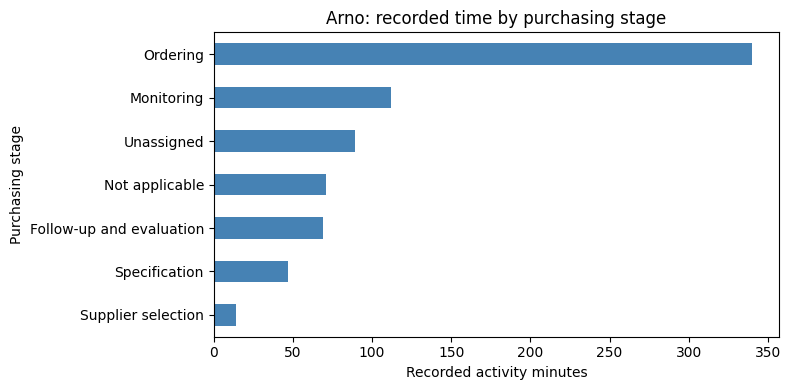

In [5]:
import matplotlib.pyplot as plt

stage_profile["minutes"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    color="steelblue"
)

plt.xlabel("Recorded activity minutes")
plt.ylabel("Purchasing stage")
plt.title("Arno: recorded time by purchasing stage")
plt.tight_layout()
plt.show()

In [6]:
# Sum minutes for each combination of day and stage
daily_minutes = (
    included.groupby(["date", "stage"])["minutes"]
    .sum(min_count=1)
    .unstack(fill_value=0)
)

# Calculate percentages within each day
daily_totals = included.groupby("date")["minutes"].sum(min_count=1)

daily_shares = daily_minutes.div(daily_totals, axis=0) * 100

# Use the same stage order as the overall profile
daily_shares = daily_shares.reindex(columns=stage_profile.index)

daily_shares.round(1)

stage,Ordering,Monitoring,Unassigned,Not applicable,Follow-up and evaluation,Specification,Supplier selection
date,,,,,,,
2026-08-31,67.0,13.6,4.9,0.0,1.9,12.6,0.0
2026-09-01,51.6,9.3,12.4,0.0,13.0,13.7,0.0
2026-09-08,39.2,0.0,18.6,2.1,29.9,6.2,4.1
2026-09-18,41.3,38.3,1.5,5.1,8.7,0.0,5.1
2026-09-23,37.3,4.3,23.2,31.9,0.0,3.2,0.0


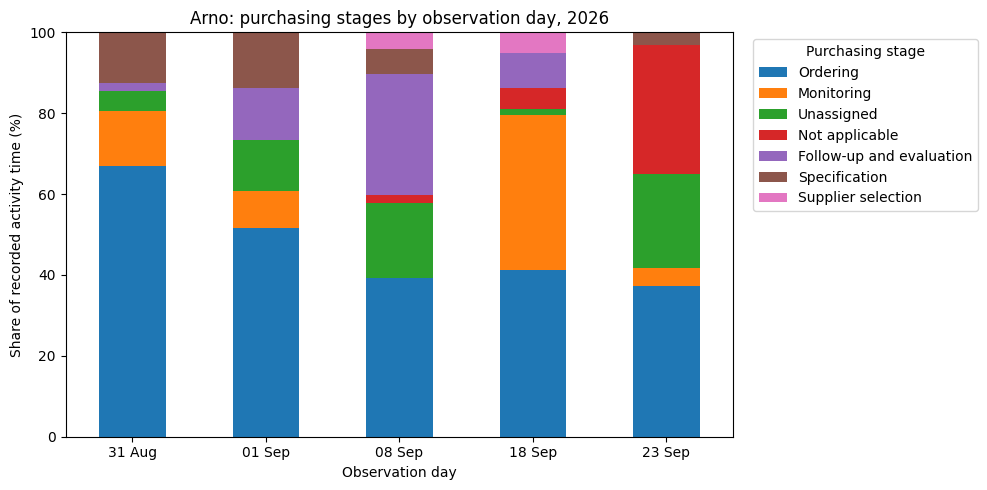

In [7]:
plot_data = daily_shares.copy()
plot_data.index = plot_data.index.strftime("%d %b")

plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel("Observation day")
plt.ylabel("Share of recorded activity time (%)")
plt.title("Arno: purchasing stages by observation day, 2026")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(
    title="Purchasing stage",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [8]:
# Select records assigned to Ordering
ordering = included.loc[included["stage"] == "Ordering"].copy()

# Summarise activities within Ordering
groups = ordering.groupby("activity_group")["minutes"]

ordering_profile = pd.DataFrame({
    "records": groups.size(),
    "timed_records": groups.count(),
    "minutes": groups.sum(min_count=1)
})

ordering_profile["untimed_records"] = (
    ordering_profile["records"] - ordering_profile["timed_records"]
)

# The denominator is now Ordering time, not total activity time
ordering_profile["share_within_ordering_pct"] = (
    ordering_profile["minutes"] / ordering["minutes"].sum() * 100
)

ordering_profile = ordering_profile.sort_values(
    "minutes", ascending=False
)

ordering_profile.round(1)

,records,timed_records,minutes,untimed_records,share_within_ordering_pct
activity_group,,,,,
PO,62,61,161.0,1,47.4
CLAR,22,21,63.0,1,18.5
SEND,29,25,49.0,4,14.4
CHECK,6,6,37.0,0,10.9
OTHER,10,9,30.0,1,8.8
DEC,3,0,NaN,3,NaN
REQ,31,0,NaN,31,NaN


In [9]:
ordering_notes = ordering.loc[
    ordering["activity_group"].isin(["PO", "CLAR"]),
    ["date", "Case", "source_row", "activity_group", "minutes", "Note"]
].sort_values(["date", "source_row"])

# Show the first 20 records with readable notes
with pd.option_context("display.max_colwidth", 180):
    display(ordering_notes.head(20))

,date,Case,source_row,activity_group,minutes,Note
3,2026-08-31,OBS-02,4,PO,2.0,NaN
6,2026-08-31,OBS-03,7,CLAR,NaN,"Forward; instantaneous/tally occurrence, not a timed episode."
9,2026-08-31,OBS-04,10,PO,2.0,1L added
16,2026-08-31,OBS-06,17,PO,4.0,NaN
19,2026-08-31,OBS-07,20,CLAR,2.0,Write up information
24,2026-08-31,OBS-07,25,CLAR,2.0,2nd item that needs be inputted; asking question
25,2026-08-31,OBS-07,26,CLAR,4.0,"2nd item, different comp."
28,2026-08-31,OBS-08,29,PO,1.0,Buy order amount of €900
31,2026-08-31,OBS-09,32,PO,1.0,"Buy amount of €2,000"
34,2026-08-31,OBS-10,35,CLAR,2.0,Credit-card action. This is a one-time purchase that is paid via credit card instead of the normal purchasing process. This case = 1 PC.


In [11]:
# Examples selected after reviewing the notes
review_cases = pd.DataFrame([
    ["2026-09-18", "OBS-10", "Drawing completeness"],
    ["2026-09-23", "OBS-12", "Drawing completeness"],
    ["2026-09-01", "OBS-02", "Quantity clarification"],
    ["2026-08-31", "OBS-07", "Item data completeness"],
    ["2026-09-01", "31AUG-OBS-07", "Item data completeness"],
    ["2026-08-31", "OBS-15", "MAX / combining demand"],
    ["2026-09-23", "OBS-19", "MAX / combining demand"]
], columns=["date", "Case", "reason_for_review"])

review_cases["date"] = pd.to_datetime(review_cases["date"])

# Retrieve all recorded activities belonging to these examples
case_details = included.merge(
    review_cases,
    on=["date", "Case"],
    how="inner",
    validate="many_to_one"
)

case_details = case_details[[
    "reason_for_review", "date", "Case", "source_row",
    "activity_group", "minutes", "Note"
]].sort_values(["reason_for_review", "date", "source_row"])

with pd.option_context(
    "display.max_colwidth", 180,
    "display.max_rows", None
):
    display(case_details)

,reason_for_review,date,Case,source_row,activity_group,minutes,Note
17,Drawing completeness,2026-09-18,OBS-10,26,REQ,NaN,NaN
18,Drawing completeness,2026-09-18,OBS-10,27,PO,7.0,Prepare drawings to attach to the PO; write down which drawings are missing.
19,Drawing completeness,2026-09-18,OBS-10,28,CLAR,2.0,Look for the relevant drawings and ask the engineer for them.
20,Drawing completeness,2026-09-18,OBS-10,40,SEND,2.0,Drawing received from the engineer.
21,Drawing completeness,2026-09-18,OBS-10,41,CLAR,4.0,Final check that the drawing and its information were complete.
22,Drawing completeness,2026-09-23,OBS-12,32,REQ,NaN,NaN
23,Drawing completeness,2026-09-23,OBS-12,33,PO,5.0,See the separate case note below.
24,Drawing completeness,2026-09-23,OBS-12,34,CLAR,5.0,"Look for the relevant drawing; unable to find it, ask a colleague."
25,Drawing completeness,2026-09-23,OBS-12,36,CLAR,3.0,/
26,Drawing completeness,2026-09-23,OBS-12,42,SEND,2.0,/


In [12]:
ordering_checks = included.loc[
    (included["stage"] == "Ordering")
    & (included["activity_group"] == "CHECK")
].copy()

with pd.option_context("display.max_colwidth", 180):
    display(ordering_checks[
        ["date", "Case", "Volume", "minutes", "Note"]
    ])

,date,Case,Volume,minutes,Note
8,2026-08-31,OBS-04,3L,1.0,1L checked
10,2026-08-31,OBS-04,3L,4.0,2L checked
92,2026-09-01,OBS-18,4L,6.0,Pre-control: delivery time adjusted; price control could not be completed because of an unpaid-invoice issue. Supplier identity omitted.
133,2026-09-08,OBS-08,7L,3.0,"Price comparison; check first the physical quotation, then the website."
220,2026-09-18,OBS-21,29L,20.0,Pre-check; one mismatch was difficult to explain. The note names Kirby.
243,2026-09-23,OBS-02,8L,3.0,Pre-control.


In [16]:
checks = included.loc[
    included["activity_group"] == "CHECK"
].copy()

# Convert values such as "3L" into numbers
checks["lines"] = pd.to_numeric(
    checks["Volume"].str.replace("L", "", regex=False).str.strip(),
    errors="coerce"
)

# 31 August: the notes explicitly record 1 and 2 checked lines
checks.loc[
    (checks["date"] == pd.Timestamp("2026-08-31"))
    & (checks["source_row"] == 9),
    "lines"
] = 1

checks.loc[
    (checks["date"] == pd.Timestamp("2026-08-31"))
    & (checks["source_row"] == 11),
    "lines"
] = 2

# Checks known to be incomplete
partial = (
    (checks["date"] == pd.Timestamp("2026-09-18"))
    & (checks["Case"] == "OBS-01")
)

blocked = (
    (checks["date"] == pd.Timestamp("2026-09-01"))
    & (checks["Case"] == "OBS-18")
)

# Keep usable timed records with a positive line count
usable_checks = checks.loc[
    ~partial
    & ~blocked
    & checks["lines"].gt(0)
    & checks["minutes"].notna()
].copy()

usable_checks

,Case,Activity,Start,End,Volume,INT,DEC?,Note,Van Weele stage,date,source_row,weekday,minutes,activity_group,stage,lines
8,OBS-04,CHECK,10:52,10:53,3L,0,NaN,1L checked,Ordering,2026-08-31,9,Monday,1.0,CHECK,Ordering,1.0
10,OBS-04,CHECK,10:55,10:59,3L,0,NaN,2L checked,Ordering,2026-08-31,11,Monday,4.0,CHECK,Ordering,2.0
12,OBS-05,CHECK,10:59,11:02,3L,0,NaN,NaN,Monitoring,2026-08-31,13,Monday,3.0,CHECK,Monitoring,3.0
44,OBS-12,CHECK,13:19,13:23,1L,0,NaN,Geen leverdatum,Monitoring,2026-08-31,45,Monday,4.0,CHECK,Monitoring,1.0
45,OBS-09,CHECK,13:23,13:24,1L,0,NaN,NaN,Monitoring,2026-08-31,46,Monday,1.0,CHECK,Monitoring,1.0
84,OBS-13,CHECK,11:55,11:56,2L,0,NaN,Two-line purchasing check; commercial value om...,Monitoring,2026-09-01,22,Tuesday,1.0,CHECK,Monitoring,2.0
85,OBS-14,CHECK,11:56,11:57,1L,0,NaN,One-line purchasing check; commercial value om...,Monitoring,2026-09-01,23,Tuesday,1.0,CHECK,Monitoring,1.0
86,OBS-15,CHECK,11:57,12:00,3L,0,NaN,Three-line purchasing check.,Monitoring,2026-09-01,24,Tuesday,3.0,CHECK,Monitoring,3.0
133,OBS-08,CHECK,11:25,11:28,7L,/,/,Price comparison; check first the physical quo...,Ordering,2026-09-08,21,Tuesday,3.0,CHECK,Ordering,7.0
171,OBS-07,CHECK,11:11,11:15,2L,/,/,Order for an article consisting of multiple co...,Monitoring,2026-09-18,17,Friday,4.0,CHECK,Monitoring,2.0


In [14]:
check_cases = usable_checks.groupby(
    ["date", "Case", "stage"],
    as_index=False
).agg(
    minutes=("minutes", "sum"),
    lines=("lines", "sum")
)

check_cases["minutes_per_line"] = (
    check_cases["minutes"] / check_cases["lines"]
)

pooled_rate = (
    check_cases["minutes"].sum()
    / check_cases["lines"].sum()
)

print("Usable case-day records:", len(check_cases))
print("CHECK minutes:", check_cases["minutes"].sum())
print("Lines:", check_cases["lines"].sum())
print("Pooled minutes per line:", round(pooled_rate, 2))

Usable case-day records: 14
CHECK minutes: 62.0
Lines: 71.0
Pooled minutes per line: 0.87


In [17]:
daily_check = check_cases.groupby("date").agg(
    cases=("Case", "size"),
    minutes=("minutes", "sum"),
    lines=("lines", "sum")
)

daily_check["minutes_per_line"] = (
    daily_check["minutes"] / daily_check["lines"]
)

daily_check.round(3)

,cases,minutes,lines,minutes_per_line
date,,,,
2026-08-31,4,13.0,8.0,1.625
2026-09-01,3,5.0,6.0,0.833
2026-09-08,1,3.0,7.0,0.429
2026-09-18,5,38.0,42.0,0.905
2026-09-23,1,3.0,8.0,0.375


In [18]:
check_by_stage = check_cases.groupby("stage").agg(
    cases=("Case", "size"),
    minutes=("minutes", "sum"),
    lines=("lines", "sum")
)

check_by_stage["minutes_per_line"] = (
    check_by_stage["minutes"] / check_by_stage["lines"]
)

check_by_stage.round(2)

,cases,minutes,lines,minutes_per_line
stage,,,,
Monitoring,10,31.0,24.0,1.29
Ordering,4,31.0,47.0,0.66


Adjusting for line volume gives a pooled CHECK rate of 0.87 minutes per line. Daily rates and stage contexts still differ. Most line counts represent recorded order size, and complete observation is not independently established for every remaining check. The rate therefore remains exploratory